In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import unicodedata

# Configurações de exibição do pandas
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [4]:
# Criar estrutura de pastas
RAIZ = Path(".")
PASTAS = [
    "dados_brutos", "dados_tratados", "notebooks", "sql",
    "dashboards", "relatorios", "apresentacao", "logs"
]

for pasta in PASTAS:
    (RAIZ / pasta).mkdir(parents=True, exist_ok=True)

print("Pastas verificadas/criadas:")
for pasta in PASTAS:
    print("-", RAIZ / pasta)

# Definir parâmetros do projeto
ARQUIVO_BRUTO = Path("dados_abertos_prf-datatran2025.csv") # Ou Path("dados_brutos/acidentes2025.csv")
ARQUIVO_BASE_ANALITICA = Path("dados_tratados/base_analitica_prf_2025.csv")
ARQUIVO_BASE_MODELAVEL = Path("dados_tratados/base_modelavel_prf_2025.csv")
ARQUIVO_DICIONARIO = Path("dados_tratados/dicionario_variaveis_modulo4.csv")
ARQUIVO_DECISOES = Path("logs/decisoes_tratamento_modulo4.md")
ARQUIVO_README = Path("README.md")

SEPARADOR = ";"
ENCODING_SAIDA = "utf-8-sig"

Pastas verificadas/criadas:
- dados_brutos
- dados_tratados
- notebooks
- sql
- dashboards
- relatorios
- apresentacao
- logs


In [5]:
def ler_csv_prf(caminho, sep=";", encodings=("latin1", "utf-8", "utf-8-sig")):
    ultimo_erro = None
    for enc in encodings:
        try:
            print(f"Tentando leitura com encoding={enc}...")
            return pd.read_csv(caminho, sep=sep, encoding=enc, low_memory=False)
        except Exception as erro:
            ultimo_erro = erro
            print(f"Falhou com {enc}: {erro}")
    raise ultimo_erro

df = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)
df.head()

Tentando leitura com encoding=latin1...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [6]:
def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8")
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_")
    while "__" in nome:
        nome = nome.replace("__", "_")
    return nome.strip("_")

df.columns = [normalizar_nome_coluna(c) for c in df.columns]

# Compatibilização de grafias possíveis
renomear = {"condicao_meteorologica": "condicao_metereologica"}
df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})

print("Lista final de colunas:")
print(df.columns.tolist())

Lista final de colunas:
['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


In [7]:
colunas_esperadas = [
    "data_inversa", "dia_semana", "horario", "uf", "br", "municipio",
    "causa_acidente", "tipo_acidente", "classificacao_acidente",
    "fase_dia", "condicao_metereologica", "tipo_pista", "tracado_via",
    "uso_solo", "pessoas", "mortos", "feridos_leves",
    "feridos_graves", "feridos", "veiculos"
]

faltantes = [c for c in colunas_esperadas if c not in df.columns]
print("Colunas faltantes:", faltantes)

print("\n--- Retrato Inicial ---")
print("Dimensões:", df.shape)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

display(df.head())
display(df.sample(5, random_state=42))

Colunas faltantes: []

--- Retrato Inicial ---
Dimensões: (72529, 30)
Linhas: 72529
Colunas: 30


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,2025-03-15,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,2025-07-13,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,2025-02-23,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,2025-03-13,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,2025-02-09,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


In [8]:
# Tipos de dados e memória
df.info(memory_usage="deep")

resumo_tipos = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("tipo")
    .reset_index(name="qtd_colunas")
)
display(resumo_tipos)

# Diagnóstico de valores ausentes
nulos = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": df.isna().mean() * 100
}).sort_values("perc_nulos", ascending=False)

display(nulos[nulos["qtd_nulos"] > 0])

<class 'pandas.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      72529 non-null  int64
 1   data_inversa            72529 non-null  str  
 2   dia_semana              72529 non-null  str  
 3   horario                 72529 non-null  str  
 4   uf                      72529 non-null  str  
 5   br                      72529 non-null  int64
 6   km                      72529 non-null  str  
 7   municipio               72529 non-null  str  
 8   causa_acidente          72529 non-null  str  
 9   tipo_acidente           72529 non-null  str  
 10  classificacao_acidente  72528 non-null  str  
 11  fase_dia                72529 non-null  str  
 12  sentido_via             72529 non-null  str  
 13  condicao_metereologica  72529 non-null  str  
 14  tipo_pista              72529 non-null  str  
 15  tracado_via             72529 

,tipo,qtd_colunas
0,str,20
1,int64,10


,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


In [9]:
# Remoção de duplicidades exatas
qtd_duplicadas = df.duplicated().sum()
print("Duplicidades exatas:", qtd_duplicadas)
if qtd_duplicadas > 0:
    df = df.drop_duplicates().copy()
    print("Duplicidades removidas. Nova dimensão:", df.shape)

# Cardinalidade das categorias
categoricas = df.select_dtypes(include=["object", "string"]).columns
cardinalidade = (
    df[categoricas]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .reset_index()
)
cardinalidade.columns = ["variavel", "qtd_categorias"]
display(cardinalidade.head(30))

Duplicidades exatas: 0


,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


In [10]:
colunas_numericas = [
    "br", "km", "pessoas", "mortos", "feridos", "feridos_leves",
    "feridos_graves", "ilesos", "ignorados", "veiculos"
]

for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)

br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


In [11]:
df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")
df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)

display(df[["data_inversa", "ano", "mes", "trimestre", "dia_semana_num", "fim_de_semana"]].head())

,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


In [12]:
horario_limpo = df["horario"].astype(str).str.strip()
df["hora"] = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour

# Tentativa alternativa para arquivos com HH:MM
faltou_hora = df["hora"].isna()
if faltou_hora.any():
    df.loc[faltou_hora, "hora"] = pd.to_datetime(
        horario_limpo[faltou_hora], format="%H:%M", errors="coerce"
    ).dt.hour

def classificar_turno(hora):
    if pd.isna(hora):
        return "IGNORADO"
    if 0 <= hora <= 5:
        return "MADRUGADA"
    if 6 <= hora <= 11:
        return "MANHA"
    if 12 <= hora <= 17:
        return "TARDE"
    return "NOITE"

df["turno"] = df["hora"].apply(classificar_turno)
display(df[["horario", "hora", "turno"]].head())

,horario,hora,turno
0,06:20:00,6,MANHA
1,07:50:00,7,MANHA
2,08:45:00,8,MANHA
3,11:00:00,11,MANHA
4,09:30:00,9,MANHA


In [13]:
def criar_faixa_horaria(hora):
    if pd.isna(hora):
        return "IGNORADO"
    inicio = int(hora // 3) * 3
    fim = inicio + 2
    return f"{inicio:02d}h-{fim:02d}h"

df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)
display(df["faixa_horaria"].value_counts(dropna=False).sort_index())

faixa_horaria
00h-02h     3959
03h-05h     4948
06h-08h    11517
09h-11h     9342
12h-14h     9678
15h-17h    12624
18h-20h    13473
21h-23h     6988
Name: count, dtype: int64

In [14]:
colunas_texto = df.select_dtypes(include=["object", "string"]).columns

for coluna in colunas_texto:
    df[coluna] = (
        df[coluna]
        .astype("string")
        .str.strip()
        .str.upper()
    )
    df[coluna] = df[coluna].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})

print("Colunas textuais padronizadas:", len(colunas_texto))

Colunas textuais padronizadas: 20


In [15]:
# Nulos Categóricos
categoricas_importantes = [
    "uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia",
    "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo",
    "classificacao_acidente", "dia_semana"
]

for coluna in categoricas_importantes:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna("IGNORADO")

# Nulos Numéricos de Contagem
contagens_vitimas = ["mortos", "feridos", "feridos_leves", "feridos_graves", "pessoas", "veiculos", "ilesos", "ignorados"]

for coluna in contagens_vitimas:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna(0)

print("Preenchimento de nulos concluído!")

Preenchimento de nulos concluído!


In [16]:
# Criar Alvo
df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0)

validacao_alvo = (
    df["acidente_fatal"]
    .value_counts(dropna=False)
    .rename_axis("acidente_fatal")
    .reset_index(name="qtd")
)
validacao_alvo["perc"] = validacao_alvo["qtd"] / validacao_alvo["qtd"].sum() * 100
display(validacao_alvo)

# Validar logicamente o alvo
violacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
    ((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]
print("Violações da regra do alvo:", len(violacoes))
assert len(violacoes) == 0, "Há erro na criação de acidente_fatal."

,acidente_fatal,qtd,perc
0,0,67319,92.816666
1,1,5210,7.183334


Violações da regra do alvo: 0


In [17]:
# Indicadores de Gravidade
df["total_vitimas"] = df["mortos"] + df["feridos_leves"] + df["feridos_graves"]
df["acidente_grave"] = np.where((df["mortos"] >= 1) | (df["feridos_graves"] >= 1), 1, 0)
df["indice_gravidade"] = (
    df["mortos"] * 3
    + df["feridos_graves"] * 2
    + df["feridos_leves"]
)

# BR e Chave de Localidade
def formatar_br(valor):
    if pd.isna(valor) or valor == 0:
        return "BR-IGNORADA"
    return f"BR-{int(valor):03d}"

df["br_formatada"] = df["br"].apply(formatar_br)
df["chave_localidade"] = (
    df["uf"].astype(str) + "_" +
    df["municipio"].astype(str) + "_" +
    df["br_formatada"].astype(str)
)

display(df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas", "indice_gravidade", "br_formatada", "chave_localidade"]].head())

,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade,br_formatada,chave_localidade
0,0,1,0,1,1,BR-116,SP_GUARULHOS_BR-116
1,1,1,0,2,4,BR-116,CE_PENAFORTE_BR-116
2,0,3,0,3,3,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,0,1,0,1,1,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,0,1,1,2,3,BR-251,MG_FRANCISCO SA_BR-251


Resumo do dataset: {'linhas': 72529, 'colunas': 44, 'acidentes_fatais': 5210, 'taxa_fatalidade': 0.07183333563126473, 'total_mortos': 6043, 'total_feridos': 83550}


,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088


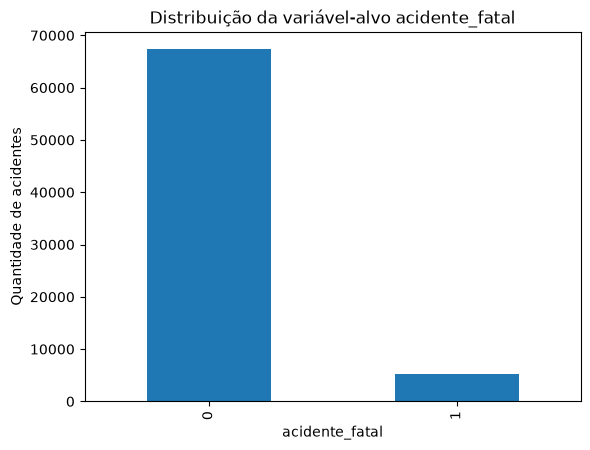

In [18]:
# Checagens rápidas
checagens = {
    "linhas": len(df),
    "colunas": df.shape[1],
    "acidentes_fatais": int(df["acidente_fatal"].sum()),
    "taxa_fatalidade": float(df["acidente_fatal"].mean()),
    "total_mortos": int(df["mortos"].sum()),
    "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None,
}
print("Resumo do dataset:", checagens)

# Ranking rápido
display(df["causa_acidente"].value_counts().head(5).reset_index(name="qtd"))

# Gráfico simples de conferência
ax = df["acidente_fatal"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribuição da variável-alvo acidente_fatal")
ax.set_xlabel("acidente_fatal")
ax.set_ylabel("Quantidade de acidentes")
plt.show()

In [19]:
base_analitica = df.copy()
print("Base analítica criada!")
print("Dimensões:", base_analitica.shape)
print("Colunas:", base_analitica.columns.tolist())

Base analítica criada!
Dimensões: (72529, 44)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana', 'hora', 'turno', 'faixa_horaria', 'acidente_fatal', 'total_vitimas', 'acidente_grave', 'indice_gravidade', 'br_formatada', 'chave_localidade']


In [20]:
# Selecionar variáveis permitidas
variaveis_modelaveis = [
    "uf", "br_formatada", "municipio", "mes", "trimestre",
    "dia_semana", "dia_semana_num", "fim_de_semana",
    "hora", "faixa_horaria", "turno", "fase_dia",
    "causa_acidente", "tipo_acidente", "condicao_metereologica",
    "tipo_pista", "tracado_via", "uso_solo",
    "acidente_fatal"
]

variaveis_modelaveis = [c for c in variaveis_modelaveis if c in df.columns]
base_modelavel = df[variaveis_modelaveis].copy()
print("Base modelável:", base_modelavel.shape)

# Verificar Data Leakage
variaveis_proibidas = [
    "mortos", "feridos", "feridos_leves", "feridos_graves",
    "total_vitimas", "indice_gravidade", "acidente_grave",
    "classificacao_acidente"
]

def verificar_data_leakage(base, proibidas):
    presentes = [c for c in proibidas if c in base.columns]
    if presentes:
        raise ValueError(f"Data leakage detectado: {presentes}")
    return "OK: Nenhuma variável proibida encontrada."

print(verificar_data_leakage(base_modelavel, variaveis_proibidas))

Base modelável: (72529, 19)
OK: Nenhuma variável proibida encontrada.


In [21]:
for coluna in base_modelavel.columns:
    if coluna == "acidente_fatal":
        continue
    if base_modelavel[coluna].dtype == "object" or str(base_modelavel[coluna].dtype) == "string":
        base_modelavel[coluna] = base_modelavel[coluna].fillna("IGNORADO")
    else:
        base_modelavel[coluna] = base_modelavel[coluna].fillna(-1)

print("Tratamento de nulos na base modelável concluído!")
print(base_modelavel.isna().sum().sort_values(ascending=False).head())

Tratamento de nulos na base modelável concluído!
uf              0
br_formatada    0
municipio       0
mes             0
trimestre       0
dtype: int64


In [22]:
# Exportar
base_analitica.to_csv(ARQUIVO_BASE_ANALITICA, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
base_modelavel.to_csv(ARQUIVO_BASE_MODELAVEL, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

# Reabrir e validar
valid_analitica = pd.read_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, encoding=ENCODING_SAIDA)
valid_modelavel = pd.read_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)

assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)
print("✅ Validação pós-exportação concluída com sucesso!")

Arquivos exportados:
- dados_tratados\base_analitica_prf_2025.csv
- dados_tratados\base_modelavel_prf_2025.csv
Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)
✅ Validação pós-exportação concluída com sucesso!


In [23]:
# 1. Dicionário de Variáveis
linhas_dic = [
    {"variavel": "acidente_fatal", "descricao": "1 se mortos >= 1; 0 se mortos = 0", "uso": "alvo"},
    {"variavel": "total_vitimas", "descricao": "mortos + feridos leves + feridos graves", "uso": "analise/dashboard"},
    {"variavel": "indice_gravidade", "descricao": "mortos*3 + feridos_graves*2 + feridos_leves", "uso": "analise/dashboard"},
    {"variavel": "br_formatada", "descricao": "BR padronizada no formato BR-000", "uso": "analise/modelagem"},
    {"variavel": "chave_localidade", "descricao": "UF + municipio + BR formatada", "uso": "analise/dashboard"},
]
dicionario = pd.DataFrame(linhas_dic)
dicionario.to_csv(ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

# 2. Decisões de Tratamento (Logs)
texto_decisoes = f"""# Decisões de Tratamento - Módulo 4
Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões
- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com pd.to_numeric(errors='coerce').
- Datas convertidas com pd.to_datetime(errors='coerce').
- Categorias ausentes relevantes preenchidas como IGNORADO.
- Variável-alvo: acidente_fatal = 1 quando mortos >= 1.
- Base modelável exclui variáveis derivadas do desfecho.

## Arquivos gerados
- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""
ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")

# 3. README.md
readme = f"""# Projeto PRF 2025

## Objetivo
Preparação dos Dados
Preparar os dados de acidentes da PRF 2025 para análise exploratória, Power BI e árvore de decisão explicável.

## Variável-alvo
`acidente_fatal`: 1 quando mortos >= 1; caso contrário, acidente_fatal = 0.

## Bases geradas
- `{ARQUIVO_BASE_ANALITICA}`: base completa para EDA e Power BI.
- `{ARQUIVO_BASE_MODELAVEL}`: base para modelagem, sem data leakage.

## Observação metodológica
A base modelável exclui mortos, feridos, total_vitimas, indice_gravidade e variáveis diretamente derivadas do desfecho.
"""
ARQUIVO_README.write_text(readme, encoding="utf-8")

print("Dicionário, Logs e README gerados com sucesso!")

Dicionário, Logs e README gerados com sucesso!


In [24]:
resumo_final = pd.DataFrame([
    {"item": "linhas_base_analitica", "valor": len(base_analitica)},
    {"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
    {"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
    {"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
    {"item": "taxa_global_acidente_fatal", "valor": base_modelavel["acidente_fatal"].mean()},
])
display(resumo_final)

,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,19.000000
4,taxa_global_acidente_fatal,0.071833
